# 🌾 AgriSmart — NB5: Validation & Error Analysis

**Objectif :** Évaluer les performances du U-Net selon les critères définis
dans le rapport (section 7.2).

## Métriques ciblées (rapport section 7.2)
- **Overall Accuracy ≥ 85%** : % de pixels correctement classifiés
- **Mean IoU ≥ 0.70** : Intersection over Union moyen sur les 6 classes
- **Per-class IoU** : identifier les classes confuses
- **Confusion matrix** : visualiser les erreurs inter-classes

## Pourquoi ces métriques ?
- **IoU** (= Jaccard index) mesure le recouvrement entre prédiction et
  label réel. C'est la métrique standard en segmentation sémantique.
  Un IoU de 0.7 signifie que 70% des pixels d'une classe sont
  correctement délimités.
- **Confusion matrix** révèle les confusions systématiques (ex : le modèle
  confond-il Sol nu et Vég. sparse ?).
- **Per-class accuracy** identifie les classes sous-performantes.

---
## 📦 Part 1 : Setup

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp
import warnings
warnings.filterwarnings('ignore')

PATCHES_DIR = Path('patches')
MODEL_PATH  = Path('models/best_unet_beja.pth')
OUTPUT_DIR  = Path('agrismart_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

N_CLASSES  = 6
N_CHANNELS = 9
BATCH_SIZE = 8   # plus grand en inference (pas de backward)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. modérée', 'Vég. dense', 'Très dense']
CLASS_COLORS = ['#8B4513', '#D2B48C', '#FFFF99', '#90EE90', '#228B22', '#006400']

print(f'🖥️  Device : {device}')
print('✅ Setup OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.4 MB/s eta 0:00:00
🖥️  Device : cpu
✅ Setup OK


---

## ⚙️ Part 1.5 : Mount Google Drive and update paths

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Update paths to point to your Google Drive
# You might need to adjust these paths based on where your data and model are stored in your Drive
PATCHES_DIR = Path('/content/drive/MyDrive/patches') # Example: assuming 'patches' folder is in MyDrive
MODEL_PATH  = Path('/content/drive/MyDrive/models/best_unet_beja.pth') # Example: assuming 'models' folder in MyDrive
OUTPUT_DIR  = Path('/content/drive/MyDrive/agrismart_outputs') # Example: assuming 'agrismart_outputs' folder in MyDrive
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'New PATCHES_DIR: {PATCHES_DIR}')
print(f'New MODEL_PATH: {MODEL_PATH}')
print(f'New OUTPUT_DIR: {OUTPUT_DIR}')
print('✅ Paths updated to Google Drive locations')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
New PATCHES_DIR: /content/drive/MyDrive/patches
New MODEL_PATH: /content/drive/MyDrive/models/best_unet_beja.pth
New OUTPUT_DIR: /content/drive/MyDrive/agrismart_outputs
✅ Paths updated to Google Drive locations


---
## 📂 Part 2 : Chargement modèle + dataset test

In [ ]:
# Modèle
model = smp.Unet(
    encoder_name='mobilenet_v2', encoder_weights=None,
    in_channels=N_CHANNELS, classes=N_CLASSES, activation=None
).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'✅ Modèle chargé (epoch {checkpoint["epoch"]})')

# Dataset test (20% du total — jamais vu pendant l'entraînement)
from torch.utils.data import Dataset, DataLoader

class TestDataset(Dataset):
    def __init__(self, patch_ids, patches_dir):
        self.ids = patch_ids
        self.dir = Path(patches_dir)
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, idx):
        pid = self.ids[idx]
        img = np.load(self.dir/'images'/f'patch_{pid:05d}.npy').astype(np.float32)
        lbl = np.load(self.dir/'labels'/f'patch_{pid:05d}.npy').astype(np.int64)
        return torch.from_numpy(img.transpose(2,0,1)), torch.from_numpy(lbl)

test_ids    = np.load(PATCHES_DIR / 'split_test.npy').tolist()
test_ds     = TestDataset(test_ids, PATCHES_DIR)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'✅ Test set : {len(test_ds):,} patches → {len(test_loader):,} batches')

✅ Modèle chargé (epoch 15)
✅ Test set : 1,171 patches → 147 batches


---
## 📊 Part 3 : Calcul des métriques sur le test set

On collecte toutes les prédictions et labels puis on calcule les métriques
une seule fois (plus stable que batch-by-batch).

In [ ]:
all_preds = []
all_labels = []

print('🔄 Inference sur test set...')
with torch.no_grad():
    for batch_idx, (imgs, lbls) in enumerate(test_loader):
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()  # (B, H, W)
        all_preds.append(preds.flatten())
        all_labels.append(lbls.numpy().flatten())

        if (batch_idx + 1) % 50 == 0:
            print(f'   {batch_idx+1}/{len(test_loader)} batches')

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(f'✅ {len(all_preds):,} pixels évalués')

🔄 Inference sur test set...
   50/147 batches
   100/147 batches
✅ 19,185,664 pixels évalués


---
## 📏 Part 4 : Overall Accuracy + Per-class IoU (Mean IoU)

In [ ]:
def compute_iou_per_class(y_true, y_pred, n_classes):
    """IoU = TP / (TP + FP + FN) pour chaque classe"""
    iou_scores = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        denom = tp + fp + fn
        iou_scores.append(tp / denom if denom > 0 else 0.0)
    return np.array(iou_scores)


# Overall Pixel Accuracy
overall_acc = np.mean(all_preds == all_labels) * 100

# Per-class IoU
iou_scores = compute_iou_per_class(all_labels, all_preds, N_CLASSES)
mean_iou   = np.mean(iou_scores)

# Per-class accuracy
per_class_acc = []
for c in range(N_CLASSES):
    mask = all_labels == c
    acc_c = np.mean(all_preds[mask] == c) * 100 if mask.sum() > 0 else 0.0
    per_class_acc.append(acc_c)

# Résumé
print('📏 MÉTRIQUES DE VALIDATION — TEST SET')
print('=' * 70)
print(f'Overall Pixel Accuracy : {overall_acc:.1f}%  (target ≥ 85%)')
print(f'Mean IoU               : {mean_iou:.3f}    (target ≥ 0.70)')
print()
print(f'{"Classe":20} | {"IoU":8} | {"Accuracy":10} | {"Status"}')
print('-' * 60)

results = []
for i in range(N_CLASSES):
    status = '✅' if iou_scores[i] >= 0.70 else '⚠️'
    print(f'{CLASS_NAMES[i]:20} | {iou_scores[i]:.3f}    | {per_class_acc[i]:7.1f}%    | {status}')
    results.append({
        'Classe': CLASS_NAMES[i],
        'IoU': round(float(iou_scores[i]), 3),
        'Accuracy_%': round(float(per_class_acc[i]), 1)
    })

print('=' * 70)
print(f'Mean IoU global : {mean_iou:.3f}')

# Alerte performance
if overall_acc >= 85 and mean_iou >= 0.70:
    print('\n🎉 Objectifs du rapport ATTEINTS ! (acc≥85%, IoU≥0.70)')
elif overall_acc >= 85:
    print('\n⚠️  Accuracy OK mais Mean IoU < 0.70 — revoir le loss weighting')
else:
    print('\n⚠️  Objectifs non atteints — voir analyse erreurs ci-dessous')

pd.DataFrame(results).to_csv(OUTPUT_DIR / 'validation_metrics.csv', index=False)
print('\n✅ Métriques sauvegardées')

📏 MÉTRIQUES DE VALIDATION — TEST SET
Overall Pixel Accuracy : 94.4%  (target ≥ 85%)
Mean IoU               : 0.807    (target ≥ 0.70)

Classe               | IoU      | Accuracy   | Status
------------------------------------------------------------
Eau/Roche            | 0.886    |    99.3%    | ✅
Sol nu               | 0.985    |    98.6%    | ✅
Vég. sparse          | 0.545    |    79.5%    | ⚠️
Vég. modérée         | 0.769    |    86.2%    | ✅
Vég. dense           | 0.787    |    86.5%    | ✅
Très dense           | 0.869    |    95.3%    | ✅
Mean IoU global : 0.807

🎉 Objectifs du rapport ATTEINTS ! (acc≥85%, IoU≥0.70)

✅ Métriques sauvegardées


---
## 🔥 Part 5 : Confusion Matrix

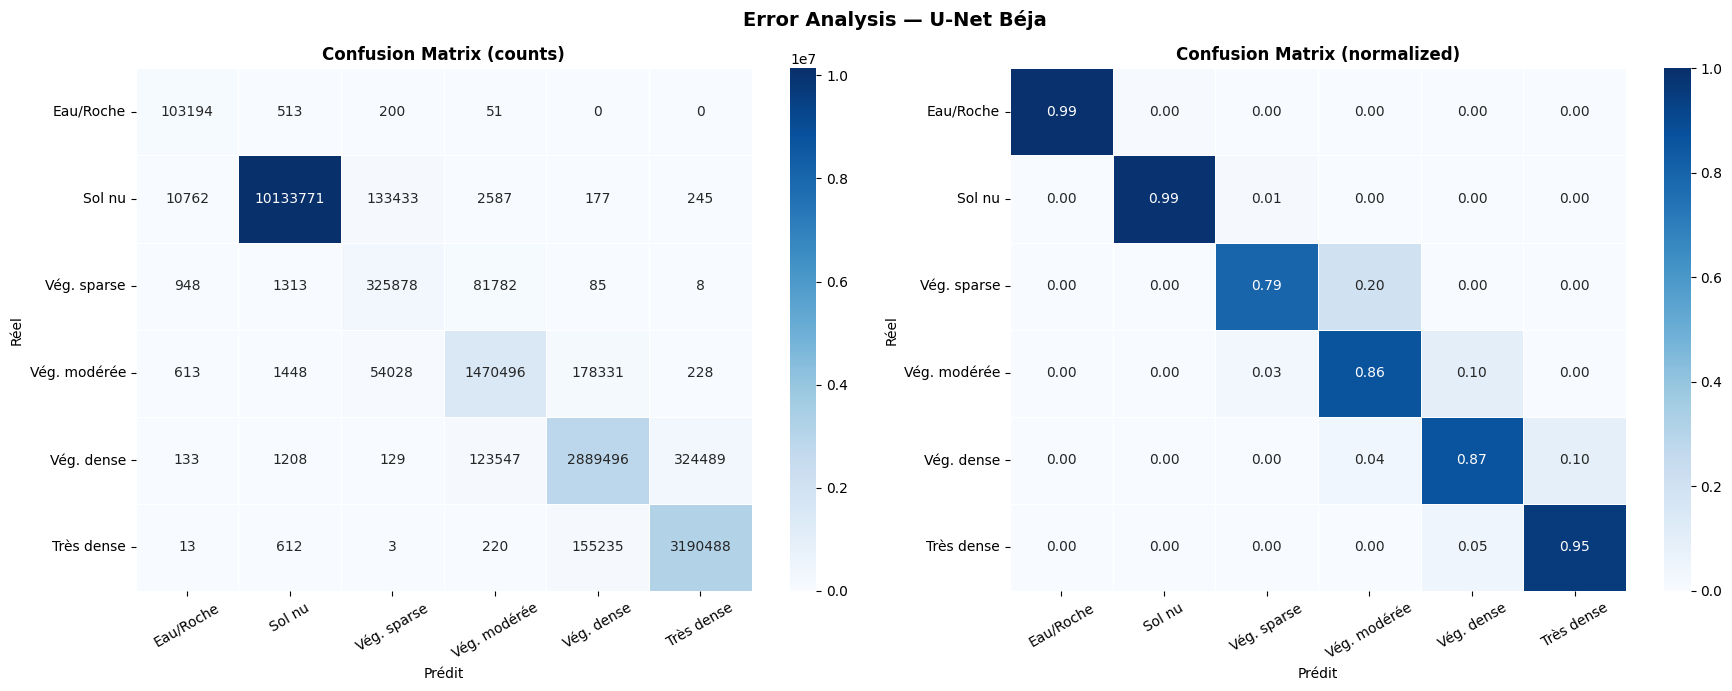


🔍 Confusions principales :
   Vég. sparse          → prédit comme Vég. modérée        : 20%
   Vég. modérée         → prédit comme Vég. dense          : 10%


In [ ]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(N_CLASSES)))

# Normaliser par classe réelle (pour voir le taux d'erreur par classe)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm /= row_sums

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion matrix brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Confusion matrix normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Error Analysis — U-Net Béja', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Identifier les confusions principales
print('\n🔍 Confusions principales :')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_norm[i, j] > 0.10:
            print(f'   {CLASS_NAMES[i]:20} → prédit comme {CLASS_NAMES[j]:20}: {cm_norm[i,j]*100:.0f}%')

---
## 📊 Part 6 : Visualisation IoU par classe

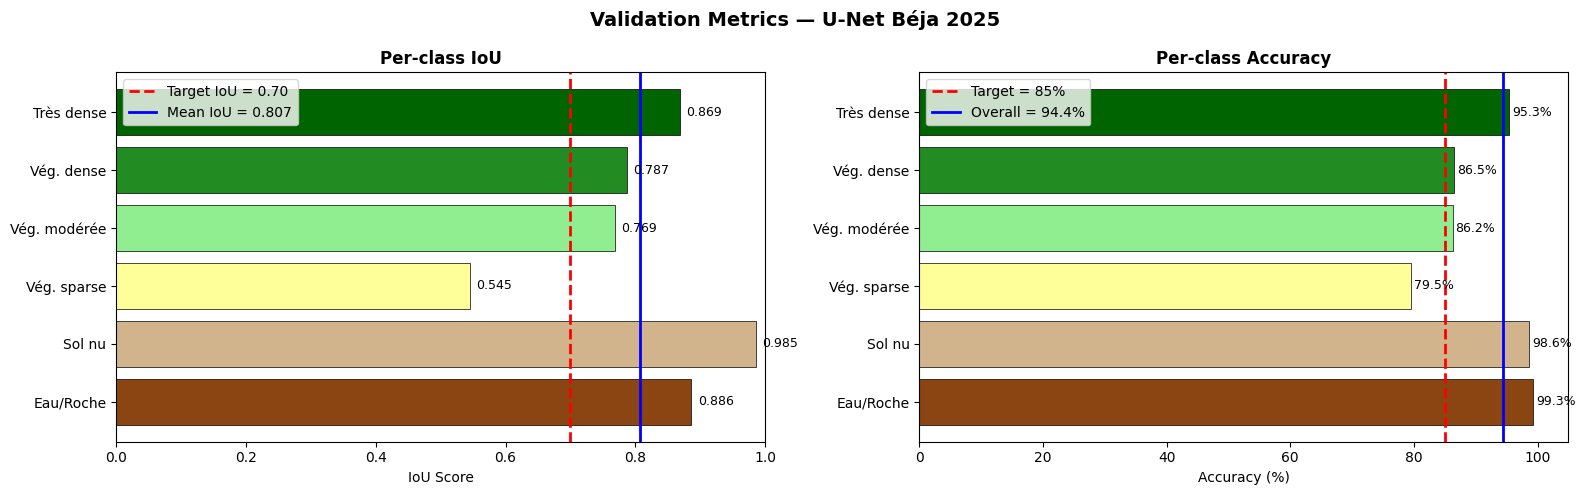

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# IoU barplot
bars = ax1.barh(CLASS_NAMES, iou_scores, color=CLASS_COLORS, edgecolor='black', linewidth=0.5)
ax1.axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='Target IoU = 0.70')
ax1.axvline(x=mean_iou, color='blue', linestyle='-', linewidth=2, label=f'Mean IoU = {mean_iou:.3f}')
ax1.set_xlabel('IoU Score')
ax1.set_title('Per-class IoU', fontweight='bold')
ax1.legend()
ax1.set_xlim(0, 1)
for bar, score in zip(bars, iou_scores):
    ax1.text(score + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)

# Accuracy barplot
bars2 = ax2.barh(CLASS_NAMES, per_class_acc, color=CLASS_COLORS, edgecolor='black', linewidth=0.5)
ax2.axvline(x=85, color='red', linestyle='--', linewidth=2, label='Target = 85%')
ax2.axvline(x=overall_acc, color='blue', linestyle='-', linewidth=2, label=f'Overall = {overall_acc:.1f}%')
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Per-class Accuracy', fontweight='bold')
ax2.legend()
ax2.set_xlim(0, 105)
for bar, acc in zip(bars2, per_class_acc):
    ax2.text(acc + 0.5, bar.get_y() + bar.get_height()/2,
             f'{acc:.1f}%', va='center', fontsize=9)

plt.suptitle('Validation Metrics — U-Net Béja 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB5_metrics_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Part 7 : Exemples d'erreurs visuelles

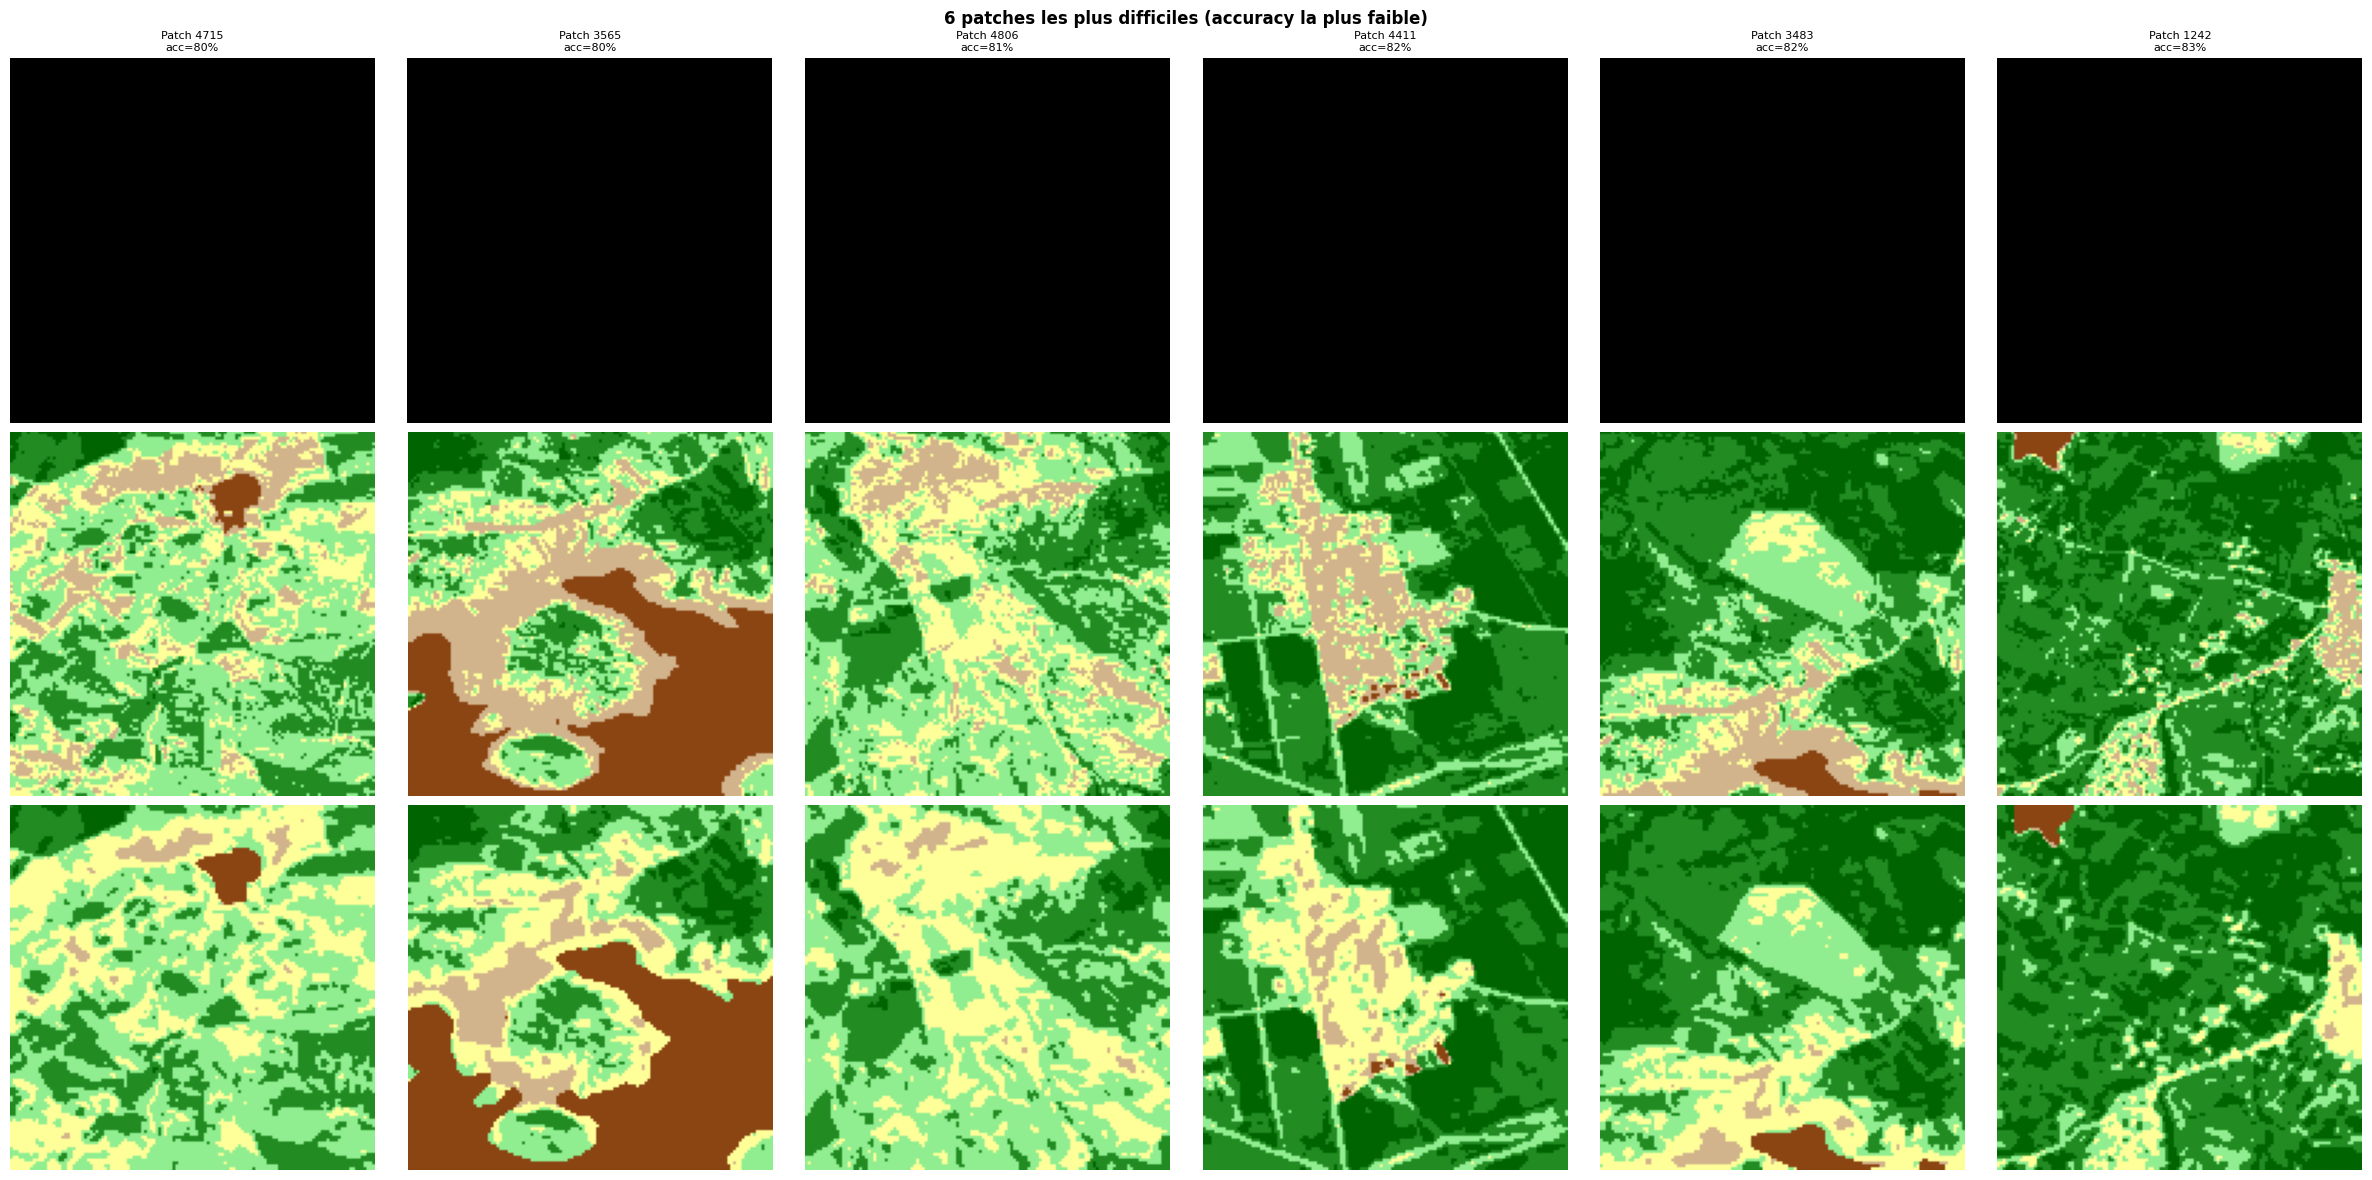

In [ ]:
# Trouver les patches avec la plus faible accuracy (pires exemples)
from matplotlib.colors import ListedColormap
cmap = ListedColormap(CLASS_COLORS)

patch_acc = []
sample_test = np.random.choice(test_ids, size=min(200, len(test_ids)), replace=False)

model.eval()
with torch.no_grad():
    for pid in sample_test:
        img_np = np.load(PATCHES_DIR/'images'/f'patch_{pid:05d}.npy').astype(np.float32)
        lbl_np = np.load(PATCHES_DIR/'labels'/f'patch_{pid:05d}.npy')
        img_t  = torch.from_numpy(img_np.transpose(2,0,1)).unsqueeze(0).to(device)
        pred   = model(img_t).argmax(dim=1).squeeze(0).cpu().numpy()
        acc    = (pred == lbl_np).mean()
        patch_acc.append((pid, acc, img_np, lbl_np, pred))

# Trier par accuracy croissante (les plus mauvais en premier)
patch_acc.sort(key=lambda x: x[1])

fig, axes = plt.subplots(3, 6, figsize=(24, 12))
for i in range(6):
    pid, acc_val, img_np, lbl_np, pred = patch_acc[i]

    rgb = img_np[:,:,[2,1,0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    axes[0,i].imshow(rgb); axes[0,i].axis('off')
    axes[0,i].set_title(f'Patch {pid}\nacc={acc_val*100:.0f}%', fontsize=8)

    axes[1,i].imshow(lbl_np, cmap=cmap, vmin=0, vmax=5); axes[1,i].axis('off')
    if i == 0: axes[1,i].set_ylabel('Label réel', fontsize=9)

    axes[2,i].imshow(pred, cmap=cmap, vmin=0, vmax=5); axes[2,i].axis('off')
    if i == 0: axes[2,i].set_ylabel('Prédiction', fontsize=9)

plt.suptitle('6 patches les plus difficiles (accuracy la plus faible)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB5_worst_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📄 Part 8 : Rapport de validation complet

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
)

print('📄 RAPPORT COMPLET DE VALIDATION')
print('=' * 70)
print(report)

# Rapport texte pour export
full_report = f"""
{'='*70}
AGRISMART — RAPPORT DE VALIDATION NB5
Béja, Tunisie | Sentinel-2 2025
{'='*70}

MODÈLE : U-Net + MobileNetV2
Epoch  : {checkpoint['epoch']}
Val Loss : {checkpoint['val_loss']:.4f}

MÉTRIQUES GLOBALES :
  Overall Pixel Accuracy : {overall_acc:.1f}%  (target ≥ 85%)
  Mean IoU               : {mean_iou:.3f}    (target ≥ 0.70)
  Status : {'✅ OBJECTIFS ATTEINTS' if overall_acc >= 85 and mean_iou >= 0.70 else '⚠️ À AMÉLIORER'}

IoU PAR CLASSE :
"""
for i in range(N_CLASSES):
    full_report += f'  {CLASS_NAMES[i]:20} : {iou_scores[i]:.3f}\n'

full_report += f"""
RAPPORT SKLEARN :
{report}

FICHIERS PRODUITS :
  NB5_confusion_matrix.png
  NB5_metrics_barplot.png
  NB5_worst_predictions.png
  validation_metrics.csv
{'='*70}
"""

with open(OUTPUT_DIR / 'NB5_validation_report.txt', 'w') as f:
    f.write(full_report)

print('\n✅ Rapport sauvegardé dans agrismart_outputs/NB5_validation_report.txt')

📄 RAPPORT COMPLET DE VALIDATION
              precision    recall  f1-score   support

   Eau/Roche      0.892     0.993     0.940    103958
      Sol nu      0.999     0.986     0.993  10280975
 Vég. sparse      0.634     0.795     0.706    410014
Vég. modérée      0.876     0.862     0.869   1705144
  Vég. dense      0.896     0.865     0.881   3339002
  Très dense      0.908     0.953     0.930   3346571

    accuracy                          0.944  19185664
   macro avg      0.868     0.909     0.886  19185664
weighted avg      0.946     0.944     0.945  19185664


✅ Rapport sauvegardé dans agrismart_outputs/NB5_validation_report.txt


---
## 🚀 Part 9 : Prochaines étapes (rapport section 8.3)

Si les objectifs ne sont pas atteints, voici les pistes :

1. **Améliorer les pseudo-labels :** Combiner NDVI + K-Means + règles expertes
2. **Augmenter les epochs :** Passer à 30-50 si la val_loss continue de baisser
3. **Changer l'encoder :** EfficientNet-B0 (légèrement plus lourde mais meilleure)
4. **Multi-temporal :** Ajouter des composites mensuels (Feb, Mar, Apr, May)
5. **Ground truth :** Terrain survey de 50 plots (rapport section 7.2)

Si les objectifs sont atteints :
- **NB6 (futur) :** Analyse multi-temporelle (rapport section 8.3)
- **NB7 (futur) :** Intégration module irrigation + maladie
- **NB8 (futur) :** Scaling à tout le territoire tunisien

In [ ]:
print('=== RÉSUMÉ FINAL NB5 ===')
print(f'Test patches      : {len(test_ds):,}')
print(f'Overall Accuracy  : {overall_acc:.1f}% (target ≥ 85%)')
print(f'Mean IoU          : {mean_iou:.3f}   (target ≥ 0.70)')
print()
for i in range(N_CLASSES):
    ok = '✅' if iou_scores[i] >= 0.70 else '⚠️'
    print(f'  {ok} {CLASS_NAMES[i]:20} IoU={iou_scores[i]:.3f}')
print()
if overall_acc >= 85 and mean_iou >= 0.70:
    print('🎉 OBJECTIFS DU RAPPORT ATTEINTS !')
    print('   → Prêt pour intégration avec modules irrigation/maladie')
else:
    print('⚠️  Objectifs non atteints → voir Part 9 pour pistes d\'amélioration')

=== RÉSUMÉ FINAL NB5 ===
Test patches      : 1,171
Overall Accuracy  : 94.4% (target ≥ 85%)
Mean IoU          : 0.807   (target ≥ 0.70)

  ✅ Eau/Roche            IoU=0.886
  ✅ Sol nu               IoU=0.985
  ⚠️ Vég. sparse          IoU=0.545
  ✅ Vég. modérée         IoU=0.769
  ✅ Vég. dense           IoU=0.787
  ✅ Très dense           IoU=0.869

🎉 OBJECTIFS DU RAPPORT ATTEINTS !
   → Prêt pour intégration avec modules irrigation/maladie


Shape : (4619, 5365)
CRS   : EPSG:4326
Résolution : (0.00017966305682390427, 0.00017968250508725318)


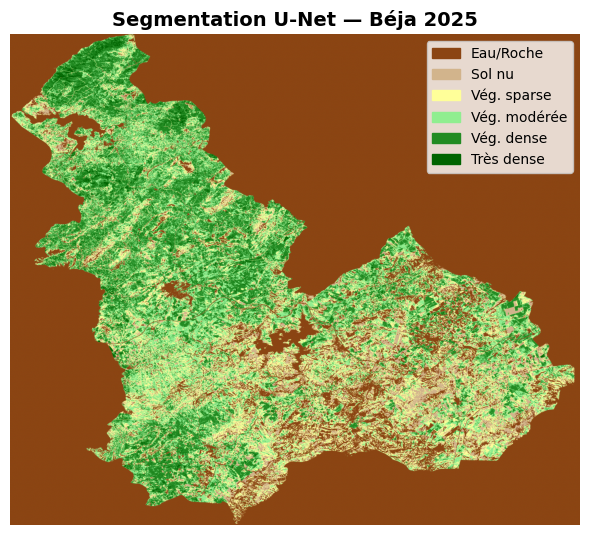

In [9]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np

# Charger le GeoTIFF
with rasterio.open('/content/drive/MyDrive/agrismart_outputs/unet_segmentation_beja_2025.tif') as src:
    pred_map = src.read(1)  # bande 1 uniquement
    print(f'Shape : {pred_map.shape}')
    print(f'CRS   : {src.crs}')
    print(f'Résolution : {src.res}')

# Afficher avec les bonnes couleurs
class_names  = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. modérée', 'Vég. dense', 'Très dense']
class_colors = ['#8B4513', '#D2B48C', '#FFFF99', '#90EE90', '#228B22', '#006400']

cmap = ListedColormap(class_colors)
patches = [mpatches.Patch(color=class_colors[i], label=class_names[i]) for i in range(6)]

plt.figure(figsize=(6, 8))
plt.imshow(pred_map, cmap=cmap, vmin=0, vmax=5)
plt.legend(handles=patches, loc='upper right', fontsize=10)
plt.title('Segmentation U-Net — Béja 2025', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('carte_finale.png', dpi=150, bbox_inches='tight')
plt.show()